In [5]:
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

np.random.seed(42)
X, y = make_circles(
    n_samples=500,
    factor=0.1,
    noise=0.35,
    random_state=42
)


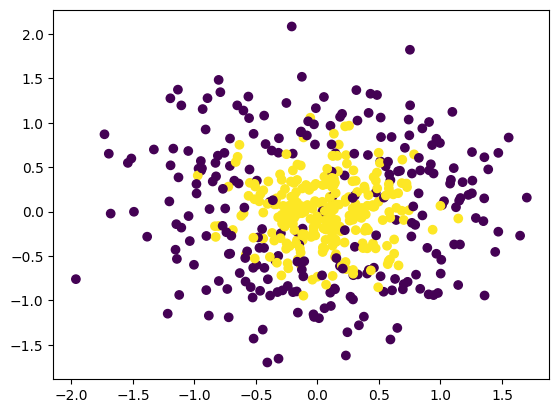

In [8]:
plt.scatter(X[:,0],X[:,1],c=y)

In [10]:
# perfor adaboost
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [11]:
ad=AdaBoostClassifier()
ad.fit(x_train,y_train)
y_pred=ad.predict(x_test)

In [13]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.86

In [18]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12,8)) # creates plot of 12*8
    x_range=np.linspace(X.min(),X.max(),100) # Creates 100 equally spaced values between the minimum and maximum values
    xx1,xx2=np.meshgrid(x_range,x_range)
    y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()]) # ravel() converts matrix to 1d array
    # np.c_ joins 2 array col wise
    y_hat=y_hat.reshape(xx1.shape)
    plt.contourf(xx1, xx2, y_hat, alpha=0.2)
    plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)

In [19]:
plt.show()

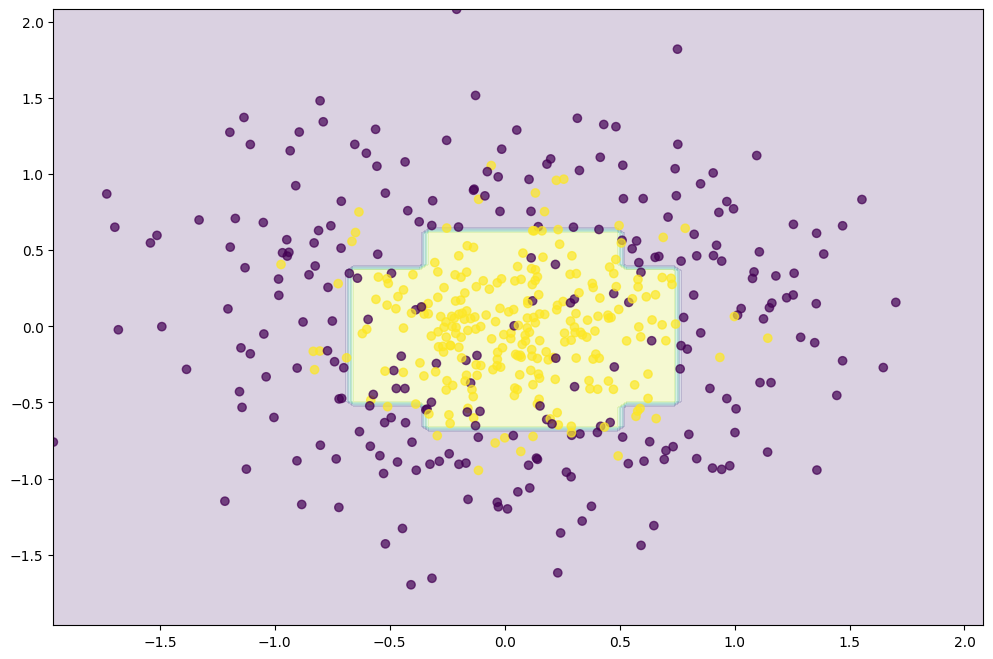

In [20]:
plot_decision_boundary(ad)

In [22]:
from sklearn.model_selection import RandomizedSearchCV

In [24]:
parameters={
    'n_estimators':[10,50,100,150],
    'learning_rate':[0.1,0.5,0.75,1],
    'algorithm':['SAMME','SAMME.R']
}

In [27]:
search=RandomizedSearchCV(AdaBoostClassifier(),parameters,cv=5,random_state=42)

In [28]:
search.fit(x_train,y_train)

C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(
C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: Fut

,estimator,AdaBoostClassifier()
,param_distributions,"{'algorithm': ['SAMME', 'SAMME.R'], 'learning_rate': [0.1, 0.5, ...], 'n_estimators': [10, 50, ...]}"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [29]:
search.best_params_

{'n_estimators': 150, 'learning_rate': 1, 'algorithm': 'SAMME'}

In [30]:
search.best_score_

np.float64(0.8100000000000002)

In [32]:
accuracy_score(y_test,search.predict(x_test))

0.86

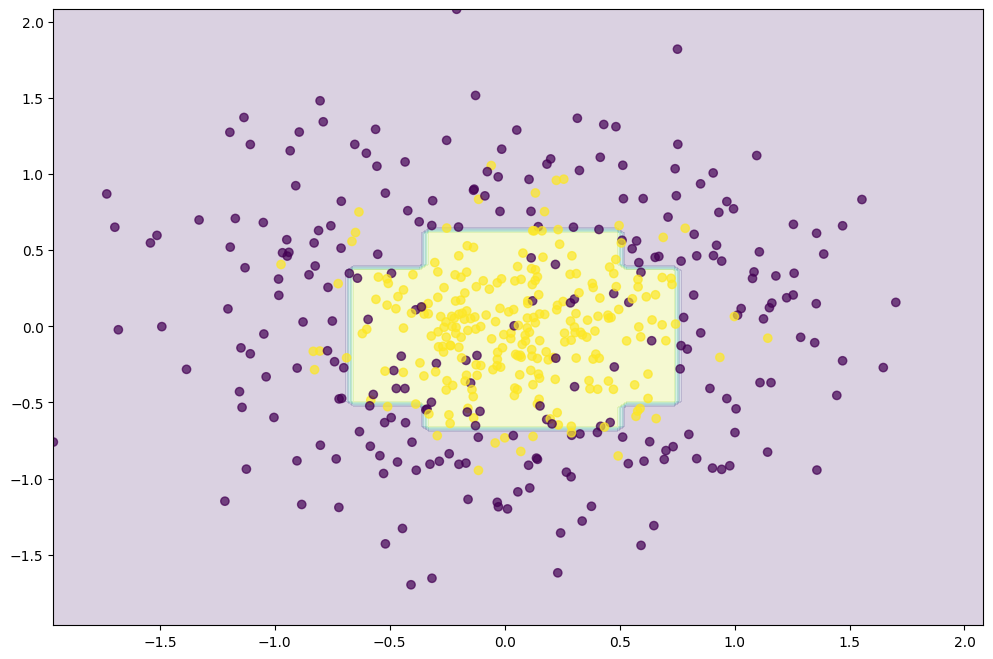

In [33]:
plot_decision_boundary(search)